In [1]:
import pandas as pd
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold, KFold
import matplotlib.pyplot as plt
import numpy as np
import sys

sys.path.insert(0, "../../utils")

from modules import *

enc = 'utf-8'

In [2]:
df_extnord = pd.read_csv(f'../../data/ExtNord/CM_ExtNord_Dataset_2015-2024.csv', encoding=enc)
df_nord = pd.read_csv(f'../../data/Nord/CM_Nord_Dataset_2015-2024.csv', encoding=enc)

dataframe = pd.concat([df_extnord, df_nord], ignore_index=True)

In [3]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

In [4]:
dataframe.head()

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,...,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2014-10,2014,10,-0.866,...,2,17,3,12,2,17,0,0,0,0
1,extreme nord,diamare,bogo,balda,14.724237,10.914551,2014-10,2014,10,-0.866,...,0,0,0,0,0,0,0,0,0,0
2,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2014-10,2014,10,-0.866,...,3,83,1,0,0,1,0,0,0,0
3,extreme nord,diamare,bogo,borai,14.606980,10.653607,2014-10,2014,10,-0.866,...,1,8,4,3,1,8,0,0,0,0
4,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2014-10,2014,10,-0.866,...,4,41,0,3,0,3,0,0,0,0


In [5]:
dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_recorded_cases', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

In [6]:
dataframe = dataframe[['location'] + dataframe.columns.to_list()[:-1]]

In [7]:
dataframe.drop(columns=['Case_UND5', 'Case_OVR5', 'Case_PRGN', 
                      'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                      'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL',
                      'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL'], inplace=True)

dataframe.rename(columns={'Case_TOTAL': 'cases'}, inplace=True)

In [8]:
dataframe.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,27.33,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,94
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,27.33,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,7
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,27.50,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,91
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,27.83,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,31
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,28.00,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,109


In [9]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [10]:
dataset = dataframe.copy()

In [11]:
dataset.sort_values(["dt_prediction", "location"], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [12]:
dataset

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,27.33,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,94
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,27.33,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,7
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,27.50,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,91
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,27.83,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,31
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,28.00,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50834,"(nord, mayo-rey, touboro, mbeing)",15.001895,7.650008,2024-09,-1.000,0.0,0.444202,0.246985,-0.353127,-0.246985,...,23.33,2746.0,582.0,0.0,91.49,1488.0,0.0,205.0,1488.0,59
50835,"(nord, mayo-rey, touboro, ngai-lara)",15.110765,7.963850,2024-09,-1.000,0.0,0.594980,0.262238,-0.460305,-0.262238,...,24.17,2791.0,626.0,0.0,97.38,1598.0,0.0,175.0,1598.0,126
50836,"(nord, mayo-rey, touboro, touboro)",15.293957,7.759324,2024-09,-1.000,0.0,0.592537,0.214245,-0.454020,-0.214245,...,24.00,2842.0,589.0,0.0,94.80,1630.0,2.0,462.0,1630.0,656
50837,"(nord, mayo-rey, touboro, vogzom)",14.714359,7.747549,2024-09,-1.000,0.0,0.599925,0.240514,-0.463363,-0.240514,...,23.83,2527.0,490.0,0.0,93.43,1316.0,0.0,163.0,1316.0,403


In [13]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50839 entries, 0 to 50838
Data columns (total 69 columns):
 #   Column                   Non-Null Count  Dtype    
---  ------                   --------------  -----    
 0   location                 50839 non-null  object   
 1   x                        50839 non-null  float64  
 2   y                        50839 non-null  float64  
 3   dt_prediction            50839 non-null  period[M]
 4   month_sin                50839 non-null  float64  
 5   month_cos                50839 non-null  float64  
 6   ndvi                     50589 non-null  float64  
 7   ndmi                     50589 non-null  float64  
 8   ndwi                     50589 non-null  float64  
 9   ndbi                     50589 non-null  float64  
 10  ndvi_mean                50722 non-null  float64  
 11  ndmi_mean                50722 non-null  float64  
 12  ndwi_mean                50722 non-null  float64  
 13  ndbi_mean                50722 non-null  float

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import KNNImputer
from Model_Validation_Module import *

In [15]:
X = dataset.select_dtypes(exclude=['object', 'period[M]']).drop(columns=['x', 'y', 'cases'])
y = dataset['cases']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# scaler = MinMaxScaler(feature_range = (-1, 1))
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [18]:
imputer = KNNImputer(n_neighbors=3)
imputer.fit(X_train_scaled)
X_train_imputed = pd.DataFrame(imputer.transform(X_train_scaled), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test.columns, index=X_test.index)

In [19]:
X_train_imputed = pd.DataFrame(scaler.inverse_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(scaler.inverse_transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

In [20]:
X_train_imputed = round_columns(X_train_imputed, round_cols, round_factor)
X_test_imputed = round_columns(X_test_imputed, round_cols, round_factor)


In [21]:
model_params = {
    'objective': 'reg:absoluteerror',
    'eval_metric': 'mae', 
    'max_depth': 10,
    'learning_rate': 0.3,
    'n_estimators': 300, 
    'min_child_weight': 3,
    'subsample': 1.0,
    'colsample_bytree': 1.0,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'random_state': 0
}

In [22]:
model = xgb.XGBRegressor(**model_params)  

In [23]:
fitted_model = model.fit(X_train_imputed, y_train)

In [24]:
y_train_proba = fitted_model.predict(X_train_imputed)
y_test_proba = fitted_model.predict(X_test_imputed)

In [25]:
y_train_pred = np.clip(np.round(y_train_proba), 0, None).astype(int)
y_test_pred = np.clip(np.round(y_test_proba), 0, None).astype(int)

In [26]:
results_train = pd.DataFrame({'actual': y_train,'prediction': y_train_pred})
results_test = pd.DataFrame({'actual': y_test,'prediction': y_test_pred})

results_test['dt_prediction'] = dataset.loc[results_test.index, 'dt_prediction']
results_test['dt_temp'] = results_test['dt_prediction']+3

results_train.reset_index(drop=True, inplace=True)
results_test.reset_index(drop=True, inplace=True)

In [27]:
metrics(results_train, results_test)

MAE on train set: 29.0088
MSE on train set: 12839.3702
min prediction: 0
max prediction: 2288

MAE on test set: 62.7449
MSE on test set: 21500.9677
min prediction: 0
max prediction: 1742


In [28]:
results_test

,actual,prediction,dt_prediction,dt_temp
0,85,50,2022-02,2022-05
1,111,120,2017-10,2018-01
2,17,43,2018-10,2019-01
3,17,8,2017-09,2017-12
4,157,48,2019-11,2020-02
...,...,...,...,...
10163,158,195,2021-03,2021-06
10164,132,100,2021-01,2021-04
10165,56,39,2016-10,2017-01
10166,771,592,2021-03,2021-06


In [29]:
results_test_lt1000 = results_test[results_test['actual'] <= 1000]
results_test_gt1000 = results_test[results_test['actual'] > 1000]

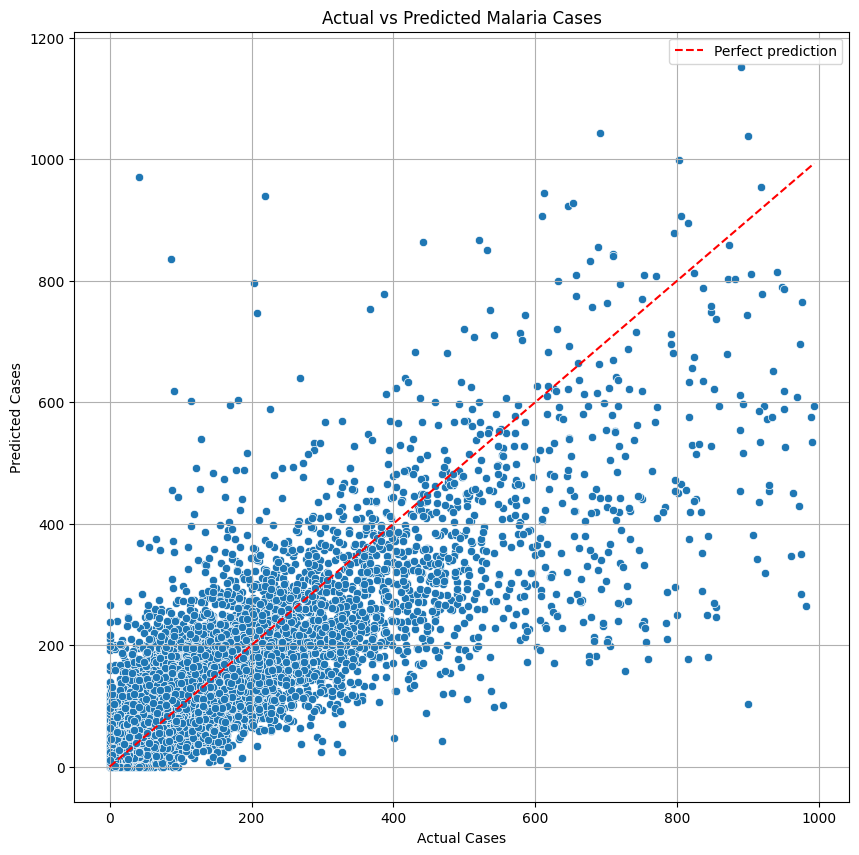

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.scatterplot(x='actual', y='prediction', data=results_test_lt1000)
plt.plot([results_test_lt1000.actual.min(), results_test_lt1000.actual.max()],
         [results_test_lt1000.actual.min(), results_test_lt1000.actual.max()],
         'r--', label='Perfect prediction')
plt.xlabel('Actual Cases')
plt.ylabel('Predicted Cases')
plt.title('Actual vs Predicted Malaria Cases')
plt.legend()
plt.grid(True)
plt.show()

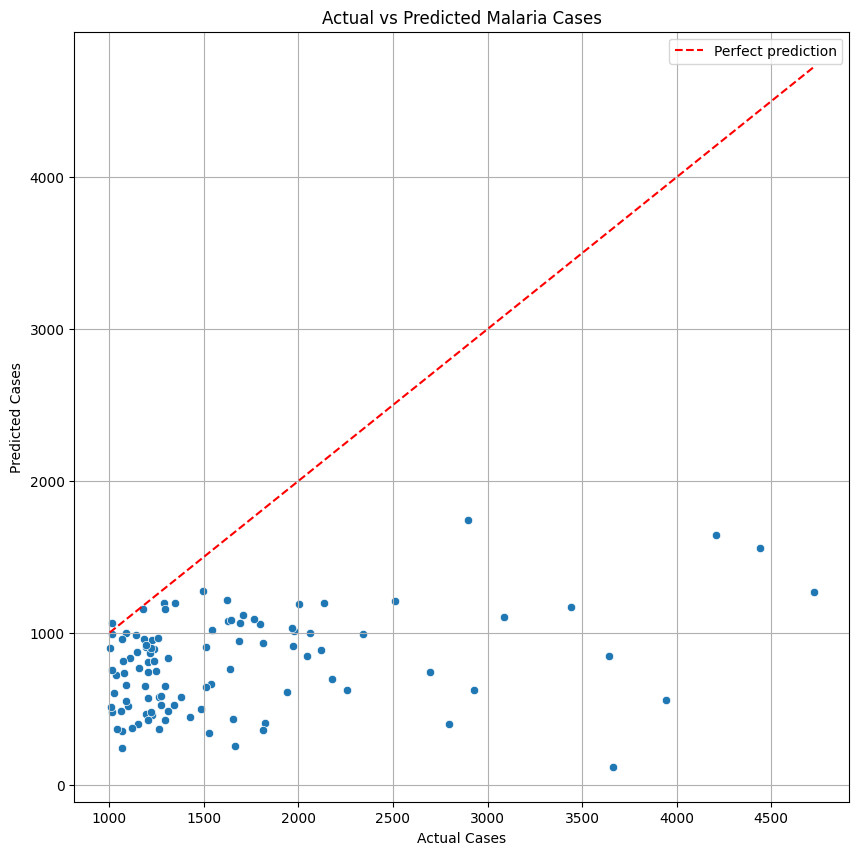

In [31]:
plt.figure(figsize=(10, 10))
sns.scatterplot(x='actual', y='prediction', data=results_test_gt1000)
plt.plot([results_test_gt1000.actual.min(), results_test_gt1000.actual.max()],
         [results_test_gt1000.actual.min(), results_test_gt1000.actual.max()],
         'r--', label='Perfect prediction')
plt.xlabel('Actual Cases')
plt.ylabel('Predicted Cases')
plt.title('Actual vs Predicted Malaria Cases')
plt.legend()
plt.grid(True)
plt.show()

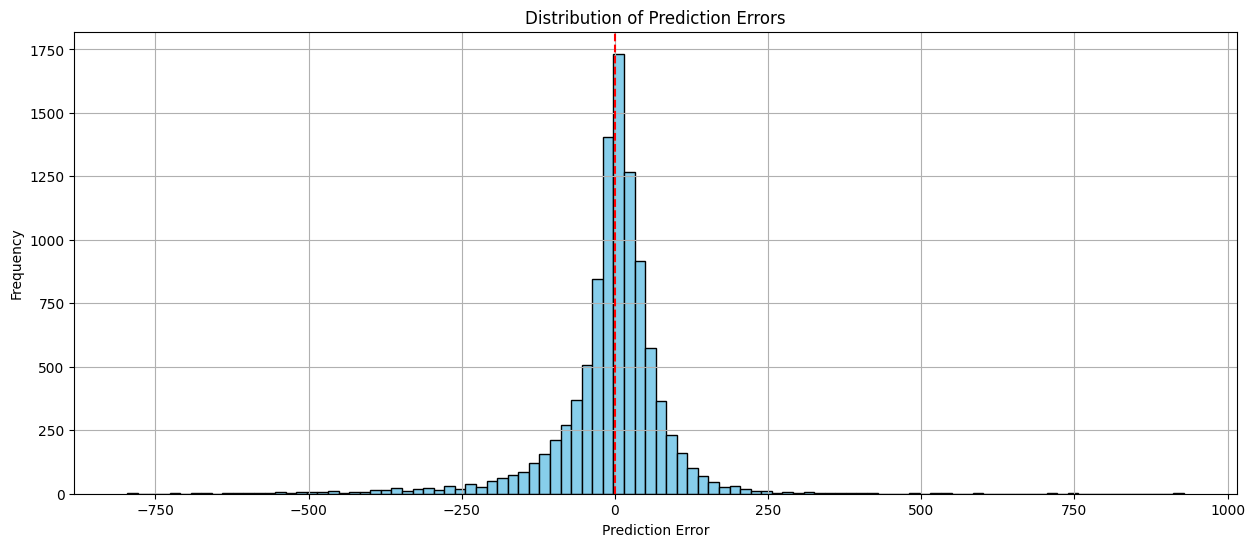

In [32]:
errors = results_test_lt1000['prediction'] - results_test_lt1000['actual']

plt.figure(figsize=(15, 6))
plt.hist(errors, bins=100, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.grid(True)
plt.show()

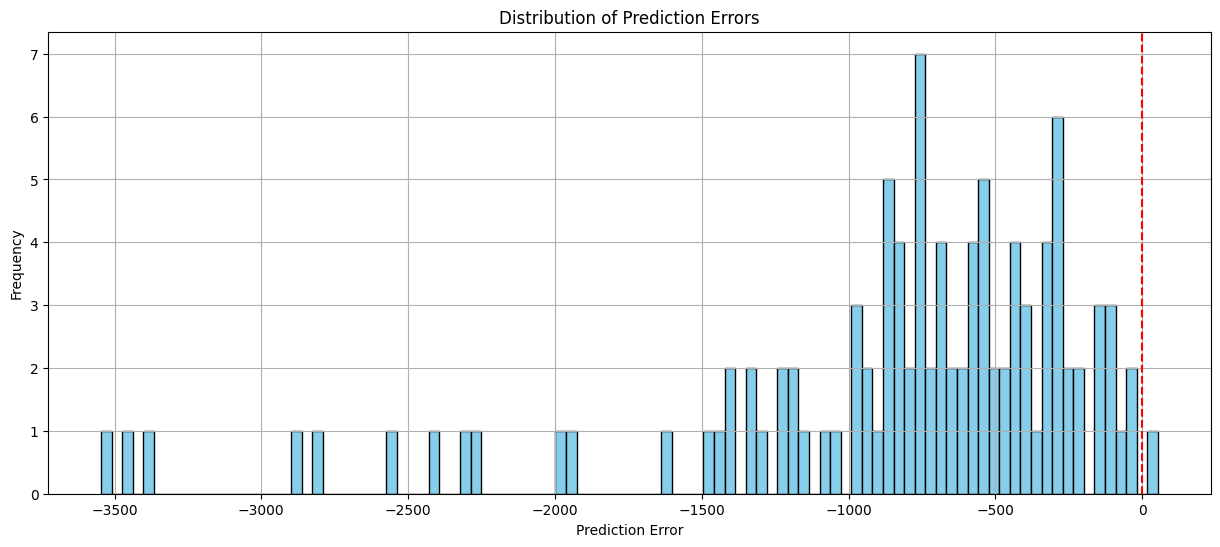

In [33]:
errors = results_test_gt1000['prediction'] - results_test_gt1000['actual']

plt.figure(figsize=(15, 6))
plt.hist(errors, bins=100, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.grid(True)
plt.show()

In [34]:
results_test_sorted = results_test.sort_values(["actual"]).copy()
results_test_sorted.reset_index(drop=True, inplace=True)

In [35]:
results_test_sorted_lt1000 = results_test_sorted[results_test_sorted['actual'] <= 1000]
results_test_sorted_gt1000 = results_test_sorted[results_test_sorted['actual'] > 1000]

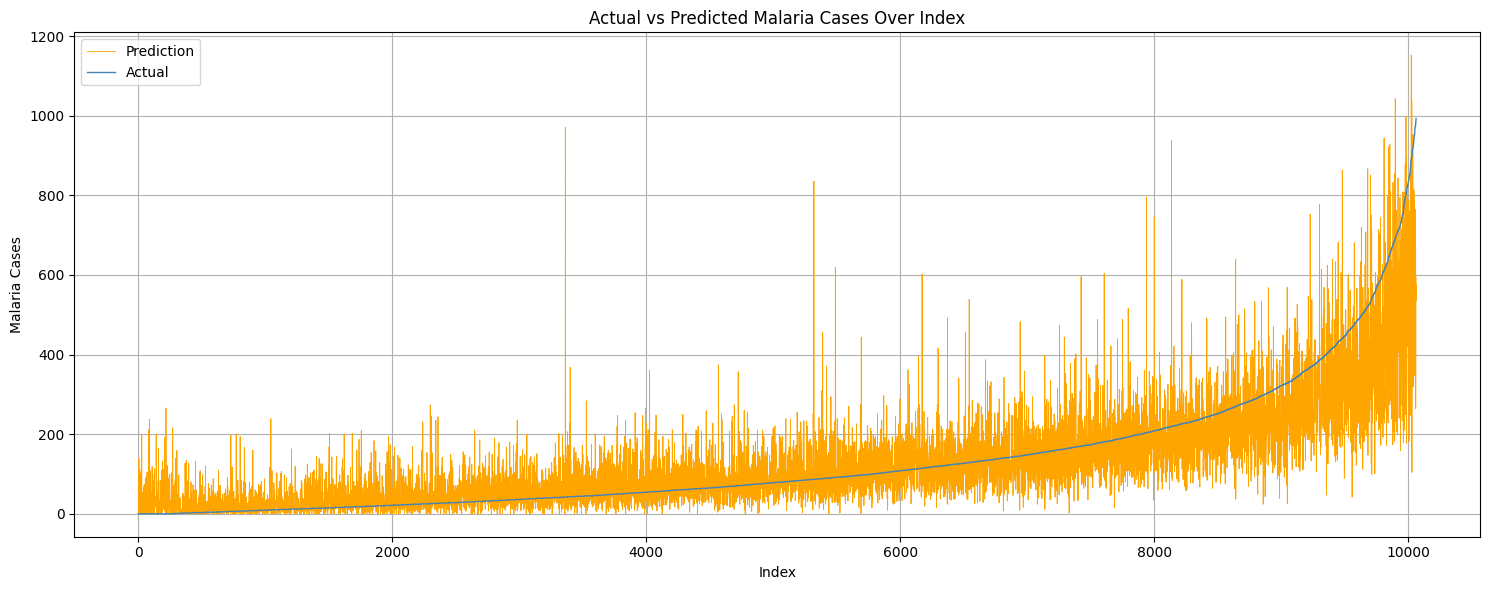

In [36]:
plt.figure(figsize=(15, 6))  # Set figure size


plt.plot(results_test_sorted_lt1000.index, results_test_sorted_lt1000['prediction'], label='Prediction', color='orange', lw = 0.6)
plt.plot(results_test_sorted_lt1000.index, results_test_sorted_lt1000['actual'], label='Actual', color='steelblue', lw= 1)

# plt.xscale('log', base=2)
# plt.yscale('log', base=2)
plt.xlabel('Index')
plt.ylabel('Malaria Cases')
plt.title('Actual vs Predicted Malaria Cases Over Index')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

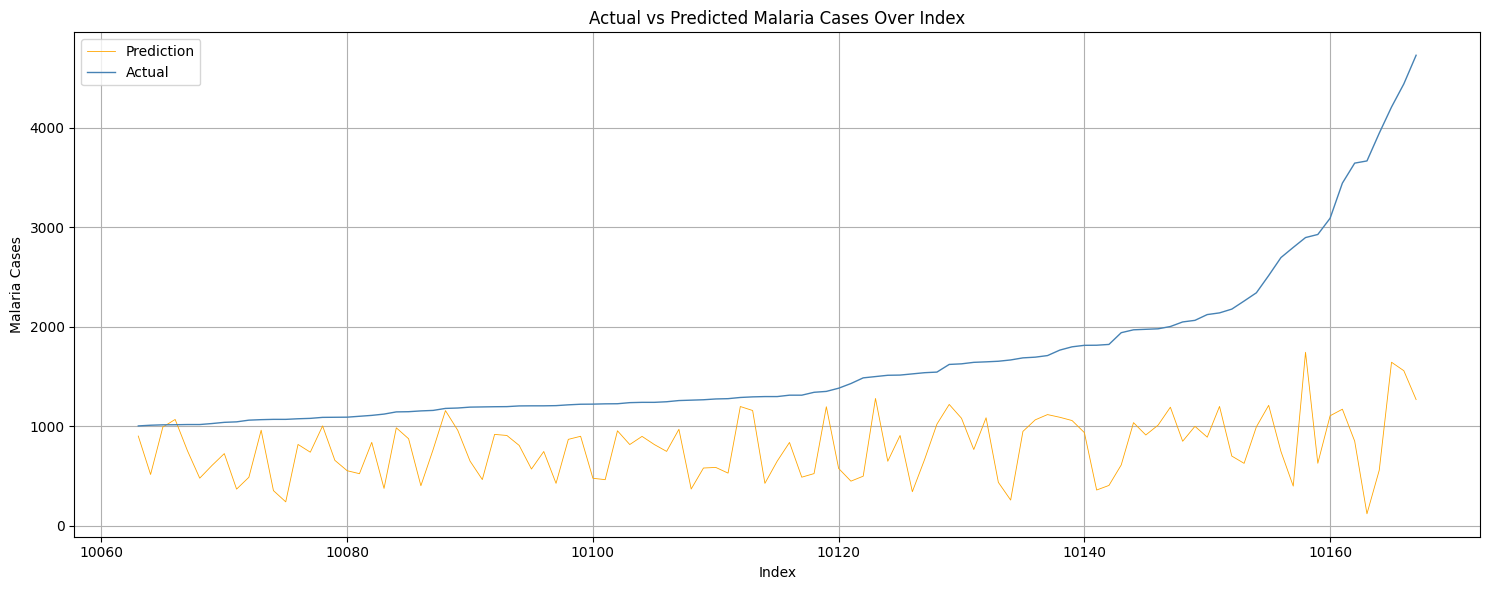

In [37]:
plt.figure(figsize=(15, 6))  # Set figure size


plt.plot(results_test_sorted_gt1000.index, results_test_sorted_gt1000['prediction'], label='Prediction', color='orange', lw = 0.6)
plt.plot(results_test_sorted_gt1000.index, results_test_sorted_gt1000['actual'], label='Actual', color='steelblue', lw= 1)

#plt.yscale('log', base=2)
plt.xlabel('Index')
plt.ylabel('Malaria Cases')
plt.title('Actual vs Predicted Malaria Cases Over Index')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()